# Shepard

Beispiel für Shepard Glissando und Tonleiter gemäß [Circularity in Judgments of Relative Pitch](https://doi.org/10.1121/1.1919362).

*Die aktuelle Implementierung ist nicht perfekt, aber schon sehr nah dran...*

In [1]:
from dhbw import dasp

import matplotlib.pyplot as plot
import numpy as np

In [2]:
fmin = 50   # base frequency in hertz
tmax = 12   # number of frequency shifts
cmax = 6    # number of frequency components
lmin = 0.1  # min. frequency component level
lmax = 0.9  # max. frequency component level

In [3]:
def theta(t, c): return 2 * np.pi * (c + t / tmax) / cmax
def level(t, c): return lmin + (lmax - lmin) * (1 - np.cos(theta(t, c))) / 2
def frequency(t, c): return fmin * 2 ** (c + t / tmax)

## Generierung der Frequenzkomponenten und deren Amplituden

In [4]:
frequencies = np.zeros((tmax, cmax))
levels = np.zeros((tmax, cmax))

for i, j in [(i, j) for i in range(tmax) for j in range(cmax)]:

    frequencies[i, j] = frequency(i, j)
    levels[i, j] = level(i, j)

## Visualisierung der Frequenzkomponenten (1)

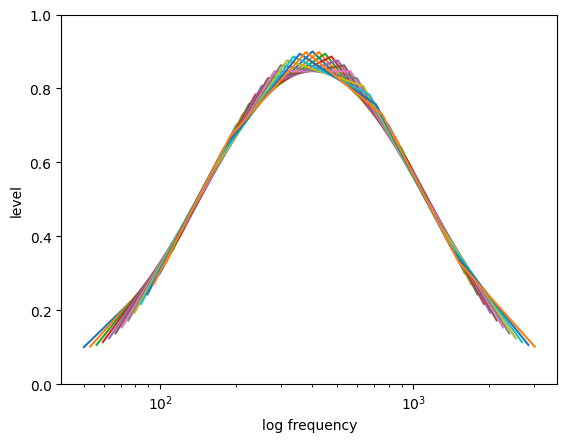

In [5]:
plot.figure()

for i in range(tmax):
    plot.plot(frequencies[i, :], levels[i, :])

plot.xscale('log')
plot.ylim(0, 1)
plot.xlabel('log frequency')
plot.ylabel('level')

plot.show()

## Visualisierung der Frequenzkomponenten (2)

<Figure size 640x480 with 0 Axes>

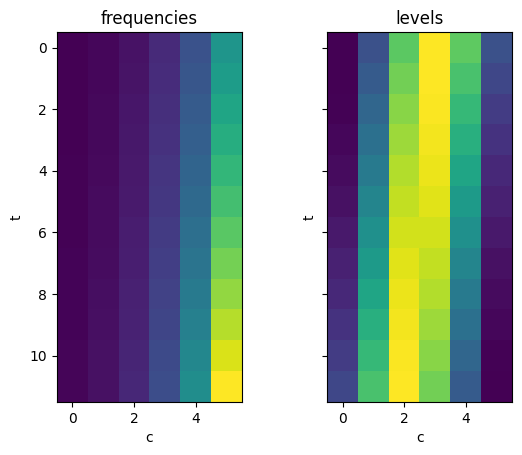

In [6]:
plot.figure()

figure, axes = plot.subplots(1, 2, sharex=True, sharey=True)

axes[0].imshow(frequencies)
axes[0].set_title('frequencies')
axes[0].set_xlabel('c')
axes[0].set_ylabel('t')

axes[1].imshow(levels)
axes[1].set_title('levels')
axes[1].set_xlabel('c')
axes[1].set_ylabel('t')

plot.show()

## Variante "Glissando"

In [7]:
x = dasp.timeline(10)
y = np.zeros(x.shape)

xmax = len(x)

n2i = np.linspace(0, tmax, xmax, endpoint=False)

for n, t in enumerate(x):

    i = n2i[n]

    for j in range(cmax):

        f = np.interp(i, range(tmax), frequencies[:, j])
        l = np.interp(i, range(tmax), levels[:, j])

        y[n] += l * np.cos(2 * np.pi * f * t) / cmax

In [8]:
dasp.io.display(y)

## Variante "Tonleiter"

In [9]:
x = dasp.timeline(10)
y = np.zeros(x.shape)

xmax = len(x)

for n, t in enumerate(x):

    i = (n * tmax) // xmax

    for j in range(cmax):

        f = frequencies[i, j]
        l = levels[i, j]

        y[n] += l * np.cos(2 * np.pi * f * t) / cmax

In [10]:
dasp.io.display(y)